# House Prices — Contribution Elastic Net alignée sur CRISP-ML

## Rôle de ce notebook

Ce notebook correspond à la **partie Elastic Net** du projet de groupe sur le challenge Kaggle **House Prices - Advanced Regression Techniques**.



1. reprendre cette baseline comme point de comparaison commun ;
2. construire une pipeline spécifique au modèle **Elastic Net** ;
3. expliquer chaque étape selon la logique **CRISP-ML** ;
4. évaluer le modèle avec un critère mathématique, informatique et métier ;
5. générer une soumission Kaggle.

## Pourquoi insister sur CRISP-ML ?

Le but n'est pas seulement d'obtenir un score Kaggle. Le notebook doit raconter une histoire de projet de data science :

- Quel problème métier cherche-t-on à résoudre ?
- Quelles données a-t-on à disposition ?
- Comment nettoie-t-on les données ?
- Pourquoi choisit-on certaines transformations ?
- Pourquoi Elastic Net est-il adapté ou limité ?
- Comment évalue-t-on le modèle ?
- Comment pourrait-on l'utiliser en production ?

# 0. Phase zéro — Use case et ML Canvas simplifié

## Use case métier

On se place dans le contexte d'une **banque** qui accompagne des clients dans l'achat, la vente ou le financement d'un bien immobilier.

Le besoin métier est le suivant :

> Estimer de manière fiable le prix de vente d'une maison à partir de ses caractéristiques afin d'aider les conseillers à prendre de meilleures décisions.

## Proposition de valeur

Le modèle peut aider la banque à :

- fournir une estimation cohérente du prix d'une maison ;
- détecter les biens potentiellement surévalués ou sous-évalués ;
- appuyer une décision d'hypothèque avec une estimation plus objective ;
- expliquer les facteurs qui influencent le prix.

## ML Canvas simplifié

| Élément | Description |
|---|---|
| Problème métier | Estimer le prix d'une maison pour soutenir les décisions immobilières/hypothécaires |
| Utilisateurs | Conseillers bancaires, analystes crédit, éventuellement clients |
| Données | Dataset Kaggle House Prices avec caractéristiques des maisons et prix de vente |
| Cible à prédire | `SalePrice`, c'est-à-dire le prix de vente |
| Type de problème | Régression supervisée, car on prédit une valeur numérique |
| Valeur ajoutée | Réduire les erreurs d'estimation et mieux comprendre les facteurs de prix |
| Risques | Biais liés au quartier, erreurs sur biens atypiques, utilisation abusive comme décision automatique |
| Déploiement théorique | Soumission Kaggle et discussion production/monitoring |

# 1. Business & Data Understanding

Dans cette phase, on cherche à comprendre les données avant de modéliser.

Le dataset contient des maisons déjà vendues. Pour chaque maison, on dispose :

- de caractéristiques numériques : surfaces, années, nombre de pièces, etc. ;
- de caractéristiques catégorielles : quartier, type de maison, type de garage, etc. ;
- de caractéristiques ordinales : qualité excellente, bonne, moyenne, faible, etc. ;
- du prix réel `SalePrice` pour les maisons du fichier `train.csv`.

Le fichier `test.csv` contient les mêmes caractéristiques, mais pas le prix. C'est ce fichier qui sert à générer la soumission Kaggle.

In [1]:
# =============================
# 1. Imports et configuration
# =============================

# numpy sert aux calculs numériques.
import numpy as np

# pandas sert à manipuler les tableaux de données.
import pandas as pd

# pathlib permet de gérer les chemins de fichiers de manière propre.
from pathlib import Path

# zipfile permet de lire le fichier zip Kaggle si les CSV ne sont pas déjà extraits.
import zipfile

# warnings permet de masquer certains avertissements non bloquants pour garder le notebook lisible.
import warnings
warnings.filterwarnings("ignore")

# matplotlib sert à faire les graphiques demandés dans l'évaluation.
import matplotlib.pyplot as plt

# Les classes suivantes permettent de créer des objets compatibles avec scikit-learn.
# C'est utile pour créer notre propre pipeline de preprocessing.
from sklearn.base import BaseEstimator, TransformerMixin

# Modèles utilisés :
# - LinearRegression pour reprendre la baseline commune M0.
# - ElasticNetCV pour tester Elastic Net avec choix automatique des hyperparamètres.
from sklearn.linear_model import LinearRegression, ElasticNetCV, ElasticNet

# Pipeline permet d'enchaîner preprocessing + modèle.
from sklearn.pipeline import Pipeline

# KFold sert à faire une validation croisée reproductible.
from sklearn.model_selection import KFold, cross_validate, cross_val_predict

# Métriques utilisées pour évaluer le modèle.
from sklearn.metrics import (
    make_scorer,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

# StandardScaler standardise les variables pour Elastic Net.
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Option d'affichage pandas : plus pratique pour voir les colonnes.
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 180)

# Graine aléatoire pour que les résultats soient reproductibles.
RANDOM_STATE = 42

# display permet d'afficher proprement des DataFrames dans Jupyter.
from IPython.display import display


In [2]:
# =============================
# 2. Chargement robuste des données
# =============================

# Pourquoi une fonction de chargement ?
# Parce que selon l'ordinateur, les fichiers peuvent être :
# - dans un dossier Data/ comme dans le notebook M0 d'Alain ;
# - directement dans le dossier courant ;
# - dans le dossier /mnt/data/house_prices_data ;
# - encore dans le ZIP téléchargé depuis Kaggle.


def load_house_prices_data():
    """Charge train.csv, test.csv et sample_submission.csv depuis plusieurs emplacements possibles."""
    possible_dirs = [
        Path("Data"),
        Path("."),
        Path("house_prices_data"),
        Path("/mnt/data/house_prices_data"),
    ]

    for data_dir in possible_dirs:
        train_path = data_dir / "train.csv"
        test_path = data_dir / "test.csv"
        sample_path = data_dir / "sample_submission.csv"
        if train_path.exists() and test_path.exists() and sample_path.exists():
            print(f"Données chargées depuis : {data_dir.resolve()}")
            return pd.read_csv(train_path), pd.read_csv(test_path), pd.read_csv(sample_path)

    # Si les CSV ne sont pas trouvés, on cherche le ZIP Kaggle.
    zip_candidates = list(Path(".").glob("house-prices-advanced-regression-techniques*.zip")) + \
                     list(Path("/mnt/data").glob("house-prices-advanced-regression-techniques*.zip"))

    if zip_candidates:
        zip_path = zip_candidates[0]
        print(f"CSV non trouvés directement. Lecture depuis le ZIP : {zip_path}")
        with zipfile.ZipFile(zip_path, "r") as z:
            train = pd.read_csv(z.open("train.csv"))
            test = pd.read_csv(z.open("test.csv"))
            sample = pd.read_csv(z.open("sample_submission.csv"))
        return train, test, sample

    raise FileNotFoundError("Impossible de trouver train.csv, test.csv et sample_submission.csv.")


train_raw, test_raw, sample_submission = load_house_prices_data()

print("Shape train brut :", train_raw.shape)
print("Shape test brut  :", test_raw.shape)
print("Shape sample     :", sample_submission.shape)

# On affiche les premières lignes pour vérifier que les données sont correctement chargées.
display(train_raw.head())

Données chargées depuis : /home/awalther/Documents/HEG/Semestre8/DataScience/Projet/Data
Shape train brut : (1460, 81)
Shape test brut  : (1459, 80)
Shape sample     : (1459, 2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Statistiques de SalePrice :


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

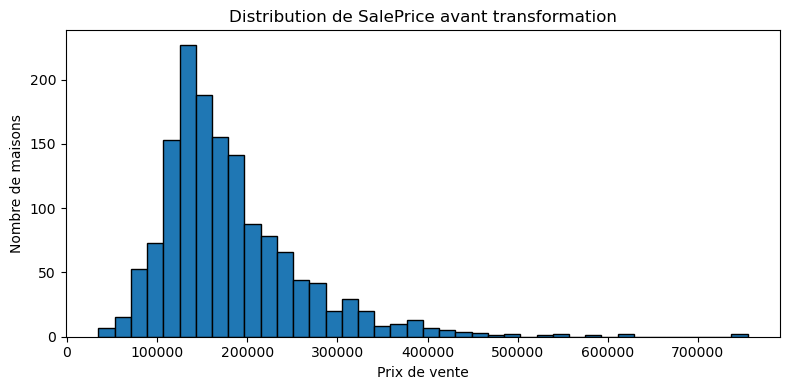

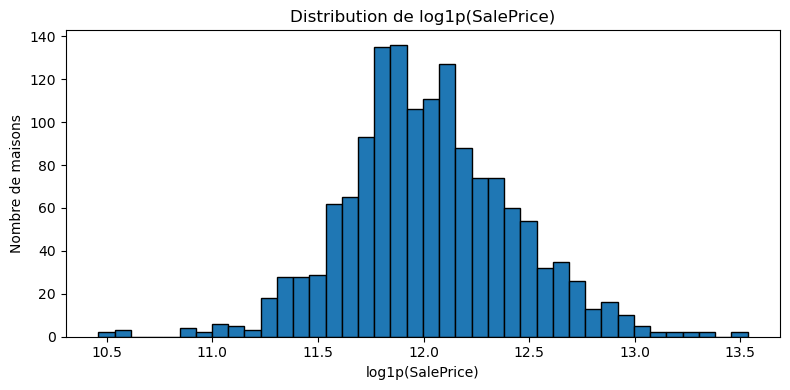

In [3]:
# =============================
# 3. Analyse rapide de la cible SalePrice
# =============================

# SalePrice est la variable cible : c'est ce que le modèle doit prédire.
# Comme on prédit un nombre, le problème est une régression.

target = "SalePrice"

print("Statistiques de SalePrice :")
display(train_raw[target].describe())

# Graphique de distribution du prix brut.
plt.figure(figsize=(8, 4))
plt.hist(train_raw[target], bins=40, edgecolor="black")
plt.title("Distribution de SalePrice avant transformation")
plt.xlabel("Prix de vente")
plt.ylabel("Nombre de maisons")
plt.tight_layout()
plt.show()

# Transformation logarithmique.
# Kaggle évalue le challenge sur une erreur logarithmique.
# Utiliser log1p(SalePrice) rend la distribution plus régulière et réduit l'influence des maisons très chères.
y_log_preview = np.log1p(train_raw[target])

plt.figure(figsize=(8, 4))
plt.hist(y_log_preview, bins=40, edgecolor="black")
plt.title("Distribution de log1p(SalePrice)")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Nombre de maisons")
plt.tight_layout()
plt.show()

## Pourquoi utiliser `log1p(SalePrice)` ?

Les prix des maisons sont très dispersés. Quelques maisons très chères peuvent influencer fortement le modèle.

En appliquant :

```python
np.log1p(SalePrice)
```

on réduit cet effet et on rapproche la cible de la logique Kaggle, qui mesure l'erreur sur une échelle logarithmique.

À la fin, pour revenir en prix réel, on utilise l'opération inverse :

```python
np.expm1(prediction_log)
```

# 2. Data Preparation — Nettoyage des données

Le nettoyage se fait avant la modélisation, mais une partie est aussi intégrée dans la pipeline.

Décisions principales :

1. **Supprimer `Id` du modèle** : l'identifiant ne décrit pas la maison, il sert seulement à la soumission Kaggle.
2. **Supprimer les outliers critiques uniquement sur le train** : on ne modifie jamais le test Kaggle.
3. **Gérer les valeurs manquantes selon leur signification** : certaines valeurs manquantes veulent dire absence de garage, absence de piscine, absence de sous-sol, etc.
4. **Créer des variables métier** avant l'encodage.
5. **Encoder les catégories** pour que le modèle puisse les utiliser.

Outliers critiques détectés : 2


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


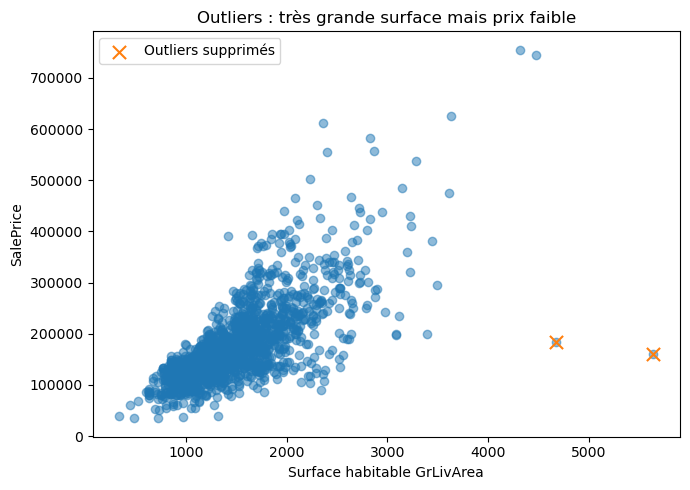

Shape train après suppression des outliers : (1458, 81)


In [4]:
# =============================
# 4. Suppression des outliers critiques sur le train uniquement
# =============================

# Dans ce dataset, une anomalie connue concerne des maisons avec une très grande surface habitable
# mais un prix étonnamment bas. Ces points peuvent perturber l'apprentissage, car ils cassent
# la relation métier logique : plus la surface est grande, plus le prix tend à augmenter.

train = train_raw.copy()
test = test_raw.copy()

# Condition utilisée dans le notebook M0 : maisons très grandes mais prix bas.
outlier_condition = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
outliers = train.loc[outlier_condition, ["Id", "GrLivArea", "SalePrice"]]

print("Outliers critiques détectés :", len(outliers))
display(outliers)

# On visualise avant suppression pour expliquer la décision.
plt.figure(figsize=(7, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.5)
plt.scatter(outliers["GrLivArea"], outliers["SalePrice"], s=90, marker="x", label="Outliers supprimés")
plt.xlabel("Surface habitable GrLivArea")
plt.ylabel("SalePrice")
plt.title("Outliers : très grande surface mais prix faible")
plt.legend()
plt.tight_layout()
plt.show()

# Suppression uniquement du train.
# Important : on ne supprime rien dans test.csv, car Kaggle attend une prédiction pour chaque Id.
train = train.loc[~outlier_condition].reset_index(drop=True)

print("Shape train après suppression des outliers :", train.shape)

In [5]:
# =============================
# 5. Séparation X / y
# =============================

# X contient les variables explicatives, c'est-à-dire les informations sur les maisons.
# y contient la cible à prédire, c'est-à-dire SalePrice.

X_all = train.drop(columns=[target])
y_all_price = train[target].copy()

# Le modèle apprend sur le log du prix.
y_all_log = np.log1p(y_all_price)

X_test_final = test.copy()

test_ids = test["Id"].copy()

print("X_all shape       :", X_all.shape)
print("y_all_log shape   :", y_all_log.shape)
print("X_test_final shape:", X_test_final.shape)

X_all shape       : (1458, 80)
y_all_log shape   : (1458,)
X_test_final shape: (1459, 80)


# 3. Baseline commune M0 — Reprise du notebook d'Alain

Dans le groupe, le notebook **M0** sert de **baseline commune**.

Son rôle est de fournir un point de comparaison simple avant de tester des modèles plus avancés.

## Baseline commune retenue

Modèle : **régression linéaire**

Variables d'entrée :

- `OverallQual` : qualité globale de la maison ;
- `GrLivArea` : surface habitable ;
- `TotalBsmtSF` : surface du sous-sol ;
- `AgeAtSale` : âge de la maison au moment de la vente ;
- `Neighborhood` : quartier.

Cette baseline est volontairement simple. Elle permet de répondre à la question :

> Est-ce que mon modèle Elastic Net apporte une amélioration par rapport à un modèle linéaire de départ ?

Dans ma partie, je garde cette baseline comme référence, puis je construis une pipeline spécifique à Elastic Net.

In [6]:
# =============================
# 6. Fonction RMSE et configuration CV
# =============================

# RMSE = Root Mean Squared Error.
# C'est l'erreur quadratique moyenne racine.
# Plus le RMSE est faible, meilleur est le modèle.
# Ici on l'applique sur log1p(SalePrice), comme dans l'esprit du score Kaggle.

def rmse(y_true, y_pred):
    """Calcule le RMSE entre les vraies valeurs et les prédictions."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Scoreur scikit-learn. Le signe négatif est nécessaire car scikit-learn maximise les scores.
rmse_scorer = make_scorer(rmse, greater_is_better=False)

# Validation croisée commune.
# shuffle=True mélange les données, random_state rend le résultat reproductible.
outer_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [7]:
# =============================
# 7. Preprocessor de la baseline M0
# =============================

class BaselineM0Preprocessor(BaseEstimator, TransformerMixin):
    """
    Preprocessing compatible avec la baseline M0 du groupe.

    Pourquoi créer une classe ?
    - Pour que le preprocessing soit appris uniquement sur le train dans chaque fold de validation.
    - Pour éviter le data leakage.
    - Pour intégrer proprement le preprocessing dans une pipeline scikit-learn.

    Transformations :
    - crée AgeAtSale = YrSold - YearBuilt ;
    - sélectionne les 5 variables M0 ;
    - impute les valeurs numériques manquantes ;
    - encode Neighborhood par target encoding lissé ;
    - ajoute des interactions polynomiales simples comme dans l'esprit du notebook M0 ;
    - standardise les variables.
    """

    def __init__(self, smoothing=10.0):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = X.copy()
        y = pd.Series(y, index=X.index)

        # Création de AgeAtSale, variable métier plus parlante que YearBuilt seul.
        X["AgeAtSale"] = X["YrSold"] - X["YearBuilt"]

        self.num_features_ = ["OverallQual", "GrLivArea", "TotalBsmtSF", "AgeAtSale"]
        self.cat_feature_ = "Neighborhood"

        # Médianes numériques apprises uniquement sur le train du fold.
        self.num_medians_ = X[self.num_features_].median()

        # Target encoding de Neighborhood.
        # On encode chaque quartier par la moyenne lissée du log-prix observé dans le train.
        self.global_mean_ = float(y.mean())
        stats = pd.DataFrame({"cat": X[self.cat_feature_].fillna("Missing"), "target": y})
        grouped = stats.groupby("cat")["target"].agg(["mean", "count"])
        smooth = (grouped["mean"] * grouped["count"] + self.global_mean_ * self.smoothing) / (grouped["count"] + self.smoothing)
        self.neighborhood_map_ = smooth.to_dict()

        # PolynomialFeatures crée des carrés et interactions entre variables numériques.
        self.poly_ = PolynomialFeatures(degree=2, include_bias=False)
        numeric_filled = X[self.num_features_].fillna(self.num_medians_)
        numeric_poly = self.poly_.fit_transform(numeric_filled)

        # On ajoute la variable Neighborhood encodée.
        neigh_te = X[self.cat_feature_].fillna("Missing").map(self.neighborhood_map_).fillna(self.global_mean_).to_numpy().reshape(-1, 1)

        features = np.hstack([numeric_poly, neigh_te])

        # Standardisation : utile pour rendre les coefficients comparables.
        self.scaler_ = StandardScaler()
        self.scaler_.fit(features)

        # Noms des features pour l'interprétation.
        poly_names = self.poly_.get_feature_names_out(self.num_features_).tolist()
        self.feature_names_ = poly_names + ["Neighborhood_te"]

        return self

    def transform(self, X):
        X = X.copy()
        X["AgeAtSale"] = X["YrSold"] - X["YearBuilt"]

        numeric_filled = X[self.num_features_].fillna(self.num_medians_)
        numeric_poly = self.poly_.transform(numeric_filled)

        neigh_te = X[self.cat_feature_].fillna("Missing").map(self.neighborhood_map_).fillna(self.global_mean_).to_numpy().reshape(-1, 1)

        features = np.hstack([numeric_poly, neigh_te])
        scaled = self.scaler_.transform(features)

        return pd.DataFrame(scaled, columns=self.feature_names_, index=X.index)


# Pipeline baseline commune.
baseline_pipeline = Pipeline(steps=[
    ("preprocessing_m0", BaselineM0Preprocessor(smoothing=10.0)),
    ("model", LinearRegression())
])

baseline_pipeline

Pipeline(steps=[('preprocessing_m0', BaselineM0Preprocessor()),
                ('model', LinearRegression())])

In [8]:
# =============================
# 8. Évaluation de la baseline commune M0
# =============================

# On évalue la baseline en validation croisée.
# return_train_score=True permet de comparer train vs validation et de détecter un éventuel overfitting.

baseline_cv_results = cross_validate(
    baseline_pipeline,
    X_all,
    y_all_log,
    cv=outer_cv,
    scoring={"rmse_log": rmse_scorer, "r2": "r2"},
    return_train_score=True,
    n_jobs=1
)

baseline_rmse_cv = -baseline_cv_results["test_rmse_log"].mean()
baseline_rmse_cv_std = baseline_cv_results["test_rmse_log"].std()
baseline_rmse_train = -baseline_cv_results["train_rmse_log"].mean()
baseline_r2_cv = baseline_cv_results["test_r2"].mean()

print("--- Baseline commune M0 ---")
print(f"RMSE log CV        : {baseline_rmse_cv:.5f} (+/- {baseline_rmse_cv_std:.5f})")
print(f"RMSE log train     : {baseline_rmse_train:.5f}")
print(f"R² moyen CV        : {baseline_r2_cv:.5f}")

if baseline_rmse_cv - baseline_rmse_train > 0.02:
    print("Attention : écart train/validation visible, possible overfitting.")
else:
    print("Pas d'overfitting majeur détecté pour la baseline.")

--- Baseline commune M0 ---
RMSE log CV        : 0.15514 (+/- 0.00622)
RMSE log train     : 0.15030
R² moyen CV        : 0.84760
Pas d'overfitting majeur détecté pour la baseline.


--- Baseline M0 : évaluation métier ---
MAE  : 19,779 $
MAPE : 11.67 %


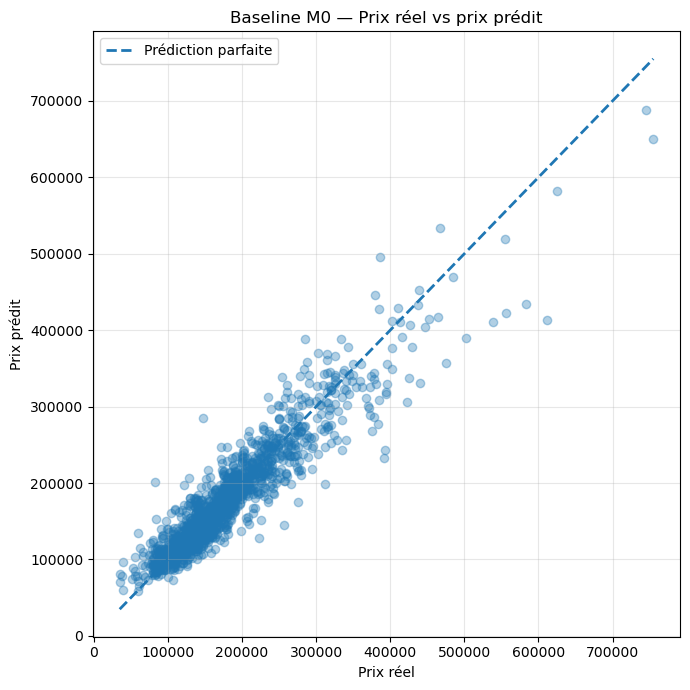

In [9]:
# =============================
# 9. Prédictions out-of-fold de la baseline pour évaluation métier
# =============================

# cross_val_predict produit des prédictions honnêtes :
# chaque ligne est prédite par un modèle qui n'a pas été entraîné sur cette ligne.

baseline_oof_log = cross_val_predict(
    baseline_pipeline,
    X_all,
    y_all_log,
    cv=outer_cv,
    n_jobs=1
)

# Retour en prix réel.
baseline_oof_price = np.expm1(baseline_oof_log)
y_price = y_all_price.values

baseline_mae = mean_absolute_error(y_price, baseline_oof_price)
baseline_mape = mean_absolute_percentage_error(y_price, baseline_oof_price) * 100

print("--- Baseline M0 : évaluation métier ---")
print(f"MAE  : {baseline_mae:,.0f} $")
print(f"MAPE : {baseline_mape:.2f} %")

# Graphe demandé : prix réel vs prix prédit.
min_axis = min(y_price.min(), baseline_oof_price.min())
max_axis = max(y_price.max(), baseline_oof_price.max())

plt.figure(figsize=(7, 7))
plt.scatter(y_price, baseline_oof_price, alpha=0.35)
plt.plot([min_axis, max_axis], [min_axis, max_axis], linestyle="--", linewidth=2, label="Prédiction parfaite")
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Baseline M0 — Prix réel vs prix prédit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Model Engineering — Pipeline spécifique Elastic Net

## Pourquoi une pipeline différente pour Elastic Net ?

Chaque modèle a ses besoins.

Elastic Net est un modèle linéaire régularisé. Il est sensible :

- à l'échelle des variables ;
- aux variables inutiles ;
- aux variables très asymétriques ;
- à la manière dont les variables catégorielles sont encodées.

Donc sa pipeline doit :

1. créer des variables métier utiles ;
2. gérer les valeurs manquantes ;
3. encoder les variables ordinales avec leur ordre réel ;
4. encoder les variables nominales sans OneHotEncoder massif ;
5. standardiser les variables ;
6. chercher les meilleurs hyperparamètres `alpha` et `l1_ratio`.

## Pourquoi éviter OneHotEncoder ici ?

On a choisi de ne pas utiliser OneHotEncoder dans ma partie Elastic Net pour garder une représentation plus compacte.

À la place :

- les variables ordinales sont converties avec un ordre métier ;
- les variables nominales sont encodées par target encoding lissé.

Cela permet d'obtenir environ 100 features finales au lieu d'exploser le nombre de colonnes.

In [10]:
# =============================
# 10. Configuration métier pour le preprocessing Elastic Net
# =============================

# Certaines valeurs manquantes signifient que l'élément n'existe pas.
# Exemple : GarageType manquant signifie souvent qu'il n'y a pas de garage.
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

# Variables ordinales : il existe un ordre logique.
# Exemple : Ex > Gd > TA > Fa > Po.
quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
exposure_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
finish_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
garage_finish_map = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
functional_map = {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8}
lot_shape_map = {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4}
land_slope_map = {"Sev": 1, "Mod": 2, "Gtl": 3}
paved_drive_map = {"N": 0, "P": 1, "Y": 2}
central_air_map = {"N": 0, "Y": 1}

ordinal_mappings = {
    "ExterQual": quality_map, "ExterCond": quality_map,
    "BsmtQual": quality_map, "BsmtCond": quality_map,
    "HeatingQC": quality_map, "KitchenQual": quality_map,
    "FireplaceQu": quality_map, "GarageQual": quality_map,
    "GarageCond": quality_map, "PoolQC": quality_map,
    "BsmtExposure": exposure_map,
    "BsmtFinType1": finish_map, "BsmtFinType2": finish_map,
    "GarageFinish": garage_finish_map,
    "Functional": functional_map,
    "LotShape": lot_shape_map,
    "LandSlope": land_slope_map,
    "PavedDrive": paved_drive_map,
    "CentralAir": central_air_map,
}

In [11]:
# =============================
# 11. Fonction de feature engineering
# =============================

# Le feature engineering consiste à créer de nouvelles variables à partir des colonnes existantes.
# Pourquoi ? Parce qu'Elastic Net est linéaire : il ne devine pas toujours les combinaisons utiles.
# On lui donne donc des variables plus proches de la logique métier.


def feature_engineer(X):
    """Crée des variables métier utiles pour estimer le prix des maisons."""
    X = X.copy()

    # Certaines colonnes numériques ont des NA dans le test.
    # On met 0 pour permettre les additions et les indicateurs de présence.
    numeric_zero_cols = [
        "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
        "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath",
        "GarageCars", "GarageArea", "Fireplaces", "PoolArea",
        "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch",
        "WoodDeckSF", "MasVnrArea"
    ]
    for col in numeric_zero_cols:
        if col in X.columns:
            X[col] = X[col].fillna(0)

    # Surface totale : sous-sol + premier étage + deuxième étage.
    X["TotalSF"] = X.get("TotalBsmtSF", 0) + X.get("1stFlrSF", 0) + X.get("2ndFlrSF", 0)

    # Âge de la maison au moment de la vente.
    X["HouseAge"] = X.get("YrSold", 0) - X.get("YearBuilt", 0)

    # Âge depuis la dernière rénovation.
    X["RemodAge"] = X.get("YrSold", 0) - X.get("YearRemodAdd", X.get("YearBuilt", 0))

    # Nombre total de salles de bain.
    X["TotalBath"] = (
        X.get("FullBath", 0) + 0.5 * X.get("HalfBath", 0) +
        X.get("BsmtFullBath", 0) + 0.5 * X.get("BsmtHalfBath", 0)
    )

    # Variables booléennes de présence.
    X["HasPool"] = (X.get("PoolArea", 0) > 0).astype(int)
    X["HasGarage"] = (X.get("GarageArea", 0) > 0).astype(int)
    X["HasFireplace"] = (X.get("Fireplaces", 0) > 0).astype(int)
    X["HasBasement"] = (X.get("TotalBsmtSF", 0) > 0).astype(int)

    # Surface des espaces extérieurs.
    X["TotalPorchSF"] = (
        X.get("OpenPorchSF", 0) + X.get("EnclosedPorch", 0) +
        X.get("3SsnPorch", 0) + X.get("ScreenPorch", 0) + X.get("WoodDeckSF", 0)
    )

    # Score global : qualité * état.
    # Une maison de très bonne qualité et bien entretenue devrait valoir plus cher.
    if "OverallQual" in X.columns and "OverallCond" in X.columns:
        X["OverallScore"] = X["OverallQual"] * X["OverallCond"]

    # Features d'interaction ajoutées pour améliorer légèrement le score Kaggle.
    # L'idée : une grande surface n'a pas le même effet si la qualité générale est faible ou élevée.
    if "OverallQual" in X.columns:
        X["OverallQual_GrLivArea"] = X["OverallQual"] * X.get("GrLivArea", 0)
        X["OverallQual_TotalSF"] = X["OverallQual"] * X.get("TotalSF", 0)
        X["OverallQual_TotalBath"] = X["OverallQual"] * X.get("TotalBath", 0)
        X["GarageCars_OverallQual"] = X.get("GarageCars", 0) * X["OverallQual"]
        X["OverallQual_HouseAge"] = X["OverallQual"] * X.get("HouseAge", 0)

    return X

In [12]:
# =============================
# 12. Preprocessor complet pour Elastic Net
# =============================

class HousePriceElasticNetPreprocessor(BaseEstimator, TransformerMixin):
    """
    Pipeline de preprocessing spécifique à Elastic Net.

    Elle est compatible avec scikit-learn, donc elle peut être utilisée dans :
    - cross-validation ;
    - cross_val_predict ;
    - pipeline finale fit/predict.

    Ce que fait cette classe :
    1. crée les variables métier ;
    2. supprime Id du modèle ;
    3. gère les valeurs manquantes ;
    4. encode les variables ordinales ;
    5. encode les variables nominales avec target encoding lissé ;
    6. applique log1p sur les variables numériques asymétriques ;
    7. standardise toutes les variables finales.
    """

    def __init__(self, smoothing=20.0, skew_threshold=0.75):
        self.smoothing = smoothing
        self.skew_threshold = skew_threshold

    def _basic_clean(self, X):
        """Nettoyage appliqué de manière identique au train et au test."""
        X = feature_engineer(X)
        X = X.copy()

        # Id ne doit pas être utilisé comme variable explicative.
        X = X.drop(columns=["Id"], errors="ignore")

        # MSSubClass est numérique dans le fichier, mais c'est en réalité une catégorie.
        if "MSSubClass" in X.columns:
            X["MSSubClass"] = X["MSSubClass"].astype(str)

        # Valeurs manquantes qui signifient absence.
        for col in none_cols:
            if col in X.columns:
                X[col] = X[col].fillna("None")

        # Encodage ordinal selon les mappings métier.
        for col, mapping in ordinal_mappings.items():
            if col in X.columns:
                X[col] = X[col].map(mapping).fillna(0).astype(float)

        # Imputation de LotFrontage par médiane du quartier.
        # Pourquoi ? Les terrains d'un même quartier ont souvent des dimensions similaires.
        if "LotFrontage" in X.columns:
            if hasattr(self, "lotfrontage_by_neighborhood_") and "Neighborhood" in X.columns:
                X["LotFrontage"] = X["LotFrontage"].fillna(X["Neighborhood"].map(self.lotfrontage_by_neighborhood_))
            if hasattr(self, "lotfrontage_global_"):
                X["LotFrontage"] = X["LotFrontage"].fillna(self.lotfrontage_global_)
            else:
                X["LotFrontage"] = X["LotFrontage"].fillna(X["LotFrontage"].median())

        return X

    def fit(self, X, y):
        X = X.copy()
        y = pd.Series(y, index=X.index)

        # Apprentissage de l'imputation LotFrontage sur le train uniquement.
        if "Neighborhood" in X.columns and "LotFrontage" in X.columns:
            self.lotfrontage_by_neighborhood_ = X.groupby("Neighborhood")["LotFrontage"].median().to_dict()
            self.lotfrontage_global_ = float(X["LotFrontage"].median())
        else:
            self.lotfrontage_by_neighborhood_ = {}
            self.lotfrontage_global_ = 0.0

        Xc = self._basic_clean(X)

        # On sépare colonnes numériques et nominales.
        self.numeric_cols_ = Xc.select_dtypes(include=[np.number]).columns.tolist()
        self.nominal_cols_ = Xc.select_dtypes(exclude=[np.number]).columns.tolist()

        # Médianes numériques apprises sur le train.
        self.numeric_medians_ = Xc[self.numeric_cols_].median()

        # Détection des variables asymétriques.
        # On applique log1p uniquement sur des variables non négatives.
        skewness = Xc[self.numeric_cols_].fillna(self.numeric_medians_).skew(numeric_only=True)
        self.skewed_cols_ = [
            col for col in self.numeric_cols_
            if abs(skewness.get(col, 0)) > self.skew_threshold and Xc[col].min(skipna=True) >= 0
        ]

        # Target encoding lissé pour les variables nominales.
        self.global_mean_ = float(y.mean())
        self.target_maps_ = {}
        for col in self.nominal_cols_:
            stats = pd.DataFrame({"cat": Xc[col].fillna("Missing"), "target": y})
            grouped = stats.groupby("cat")["target"].agg(["mean", "count"])
            smooth = (grouped["mean"] * grouped["count"] + self.global_mean_ * self.smoothing) / (grouped["count"] + self.smoothing)
            self.target_maps_[col] = smooth.to_dict()

        # On construit les features non standardisées du train pour apprendre le scaler.
        raw_features = self._make_feature_matrix(Xc)
        self.feature_names_ = raw_features.columns.tolist()

        self.scaler_ = StandardScaler()
        self.scaler_.fit(raw_features)

        return self

    def _make_feature_matrix(self, Xc):
        """Construit le tableau final avant standardisation."""
        out = pd.DataFrame(index=Xc.index)

        # Variables numériques.
        for col in self.numeric_cols_:
            s = Xc[col].copy()
            s = s.fillna(self.numeric_medians_.get(col, 0))
            if col in self.skewed_cols_:
                # On clippe à 0 par sécurité pour log1p.
                s = np.log1p(s.clip(lower=0))
            out[col] = s.astype(float)

        # Variables nominales encodées par target encoding.
        for col in self.nominal_cols_:
            encoded = Xc[col].fillna("Missing").map(self.target_maps_.get(col, {})).fillna(self.global_mean_)
            out[col + "_te"] = encoded.astype(float)

        return out

    def transform(self, X):
        Xc = self._basic_clean(X)
        raw_features = self._make_feature_matrix(Xc)

        # Sécurité : même ordre de colonnes qu'au fit.
        raw_features = raw_features.reindex(columns=self.feature_names_, fill_value=0)

        scaled = self.scaler_.transform(raw_features)
        return pd.DataFrame(scaled, columns=self.feature_names_, index=X.index)

In [13]:
# =============================
# 13. Recherche des hyperparamètres Elastic Net
# =============================

# Elastic Net combine Ridge et Lasso :
# - Ridge réduit les coefficients trop grands ;
# - Lasso peut mettre certains coefficients à zéro ;
# - Elastic Net fait un compromis entre les deux.

# alpha contrôle la force de régularisation.
# l1_ratio contrôle le mélange Ridge/Lasso :
# - proche de 0 : comportement plus Ridge ;
# - proche de 1 : comportement plus Lasso.

# Pour garder le notebook raisonnablement rapide, on fait d'abord une recherche d'hyperparamètres
# avec ElasticNetCV sur le jeu d'entraînement. Ensuite, on évalue un ElasticNet fixé avec ces paramètres
# avec la même validation croisée que la baseline.

elastic_search = ElasticNetCV(
    l1_ratio=[0.1, 0.2, 0.4],
    alphas=[0.005, 0.01, 0.012, 0.015, 0.02, 0.05],
    cv=3,
    max_iter=100000,
    random_state=RANDOM_STATE,
    n_jobs=1
)

elastic_search_pipeline = Pipeline(steps=[
    ("preprocessing_elastic", HousePriceElasticNetPreprocessor(smoothing=20.0, skew_threshold=0.75)),
    ("model", elastic_search)
])

print("Recherche des meilleurs hyperparamètres Elastic Net...")
elastic_search_pipeline.fit(X_all, y_all_log)

best_alpha = elastic_search_pipeline.named_steps["model"].alpha_
best_l1_ratio = elastic_search_pipeline.named_steps["model"].l1_ratio_

print(f"Meilleur alpha trouvé    : {best_alpha}")
print(f"Meilleur l1_ratio trouvé : {best_l1_ratio}")

# Pipeline finale utilisée pour l'évaluation et la soumission.
# Elle reprend exactement les hyperparamètres trouvés ci-dessus.
elastic_pipeline = Pipeline(steps=[
    ("preprocessing_elastic", HousePriceElasticNetPreprocessor(smoothing=20.0, skew_threshold=0.75)),
    ("model", ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=100000, random_state=RANDOM_STATE))
])

elastic_pipeline

Recherche des meilleurs hyperparamètres Elastic Net...


Meilleur alpha trouvé    : 0.012
Meilleur l1_ratio trouvé : 0.2


Pipeline(steps=[('preprocessing_elastic', HousePriceElasticNetPreprocessor()),
                ('model',
                 ElasticNet(alpha=np.float64(0.012), l1_ratio=np.float64(0.2),
                            max_iter=100000, random_state=42))])

# 5. Évaluation — Critères mathématique, informatique et métier

Le professeur demande de choisir et justifier les critères d'évaluation.

## Critère mathématique

On utilise le **RMSE sur `log1p(SalePrice)`**, car :

- c'est cohérent avec le challenge Kaggle ;
- il pénalise fortement les grosses erreurs ;
- il permet de comparer les modèles entre eux.

## Critère informatique

On vérifie que :

- la pipeline est reproductible ;
- les traitements sont appris sur le train uniquement ;
- la pipeline peut faire `fit()` sur `train.csv` et `predict()` sur `test.csv` ;
- il n'y a pas de fuite de données évidente.

## Critère métier

On regarde aussi l'erreur en prix réel :

- MAE : erreur moyenne en dollars ;
- MAPE : erreur moyenne en pourcentage ;
- graphique prix réel vs prix prédit.

Cela parle davantage à un métier bancaire qu'un RMSE logarithmique seul.

In [14]:
# =============================
# 14. Évaluation interne d'Elastic Net
# =============================

# On évalue Elastic Net avec la même validation croisée externe que la baseline.
# Cela permet une comparaison plus juste.

elastic_cv_results = cross_validate(
    elastic_pipeline,
    X_all,
    y_all_log,
    cv=outer_cv,
    scoring={"rmse_log": rmse_scorer, "r2": "r2"},
    return_train_score=True,
    n_jobs=1
)

elastic_rmse_cv = -elastic_cv_results["test_rmse_log"].mean()
elastic_rmse_cv_std = elastic_cv_results["test_rmse_log"].std()
elastic_rmse_train = -elastic_cv_results["train_rmse_log"].mean()
elastic_r2_cv = elastic_cv_results["test_r2"].mean()

print("--- Elastic Net ---")
print(f"RMSE log CV        : {elastic_rmse_cv:.5f} (+/- {elastic_rmse_cv_std:.5f})")
print(f"RMSE log train     : {elastic_rmse_train:.5f}")
print(f"R² moyen CV        : {elastic_r2_cv:.5f}")

print("\n--- Comparaison baseline vs Elastic Net ---")
print(f"Baseline M0 RMSE log : {baseline_rmse_cv:.5f}")
print(f"Elastic Net RMSE log : {elastic_rmse_cv:.5f}")
print(f"Amélioration interne : {baseline_rmse_cv - elastic_rmse_cv:.5f}")

if elastic_rmse_cv - elastic_rmse_train > 0.02:
    print("Attention : écart train/validation visible. Il peut y avoir un peu d'overfitting.")
else:
    print("Pas d'overfitting majeur détecté : l'écart train/validation reste raisonnable.")

--- Elastic Net ---
RMSE log CV        : 0.11500 (+/- 0.00835)
RMSE log train     : 0.10781
R² moyen CV        : 0.91624

--- Comparaison baseline vs Elastic Net ---
Baseline M0 RMSE log : 0.15514
Elastic Net RMSE log : 0.11500
Amélioration interne : 0.04014
Pas d'overfitting majeur détecté : l'écart train/validation reste raisonnable.


--- Elastic Net : évaluation métier ---
MAE  : 14,427 $
MAPE : 8.34 %

--- Gain métier vs baseline ---
MAE baseline   : 19,779 $
MAE ElasticNet : 14,427 $
Gain MAE       : 5,352 $


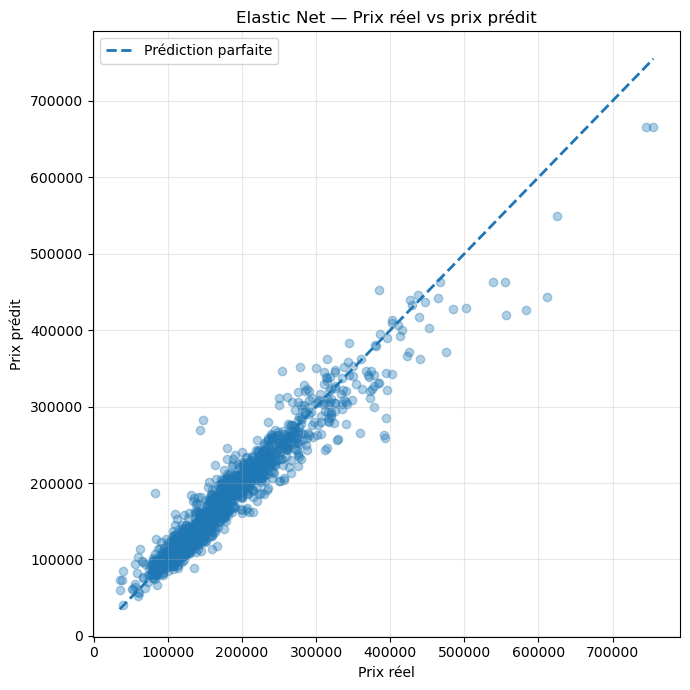

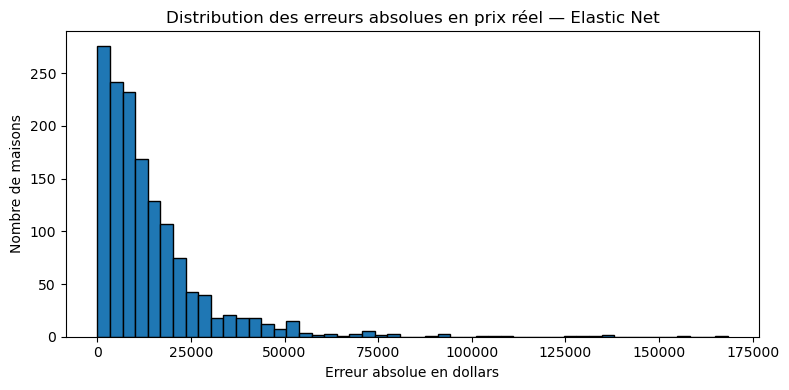

Quelques statistiques sur les erreurs absolues :
count      1458.000000
mean      14427.475935
std       16628.900505
min          20.563250
25%        4683.790432
50%        9891.824470
75%       18080.733384
max      168286.970459
dtype: float64


In [15]:
# =============================
# 15. Évaluation métier : prédiction vs réel pour Elastic Net
# =============================

# Ces prédictions sont out-of-fold : elles sont honnêtes car chaque maison est prédite par un modèle
# qui ne l'a pas vue pendant l'entraînement.

elastic_oof_log = cross_val_predict(
    elastic_pipeline,
    X_all,
    y_all_log,
    cv=outer_cv,
    n_jobs=1
)

elastic_oof_price = np.expm1(elastic_oof_log)

elastic_mae = mean_absolute_error(y_price, elastic_oof_price)
elastic_mape = mean_absolute_percentage_error(y_price, elastic_oof_price) * 100

print("--- Elastic Net : évaluation métier ---")
print(f"MAE  : {elastic_mae:,.0f} $")
print(f"MAPE : {elastic_mape:.2f} %")

print("\n--- Gain métier vs baseline ---")
print(f"MAE baseline   : {baseline_mae:,.0f} $")
print(f"MAE ElasticNet : {elastic_mae:,.0f} $")
print(f"Gain MAE       : {baseline_mae - elastic_mae:,.0f} $")

# Graphe demandé : prix réel vs prix prédit.
min_axis = min(y_price.min(), elastic_oof_price.min())
max_axis = max(y_price.max(), elastic_oof_price.max())

plt.figure(figsize=(7, 7))
plt.scatter(y_price, elastic_oof_price, alpha=0.35)
plt.plot([min_axis, max_axis], [min_axis, max_axis], linestyle="--", linewidth=2, label="Prédiction parfaite")
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Elastic Net — Prix réel vs prix prédit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Analyse des erreurs en prix réel.
errors_price = elastic_oof_price - y_price
abs_errors_price = np.abs(errors_price)

plt.figure(figsize=(8, 4))
plt.hist(abs_errors_price, bins=50, edgecolor="black")
plt.title("Distribution des erreurs absolues en prix réel — Elastic Net")
plt.xlabel("Erreur absolue en dollars")
plt.ylabel("Nombre de maisons")
plt.tight_layout()
plt.show()

print("Quelques statistiques sur les erreurs absolues :")
print(pd.Series(abs_errors_price).describe())

In [16]:
# =============================
# 16. Entraînement final sur tout le train
# =============================

# Après l'évaluation interne, on entraîne le modèle final sur toutes les données d'entraînement.
# C'est ce modèle qui sera utilisé pour prédire test.csv et générer la soumission Kaggle.

elastic_pipeline.fit(X_all, y_all_log)

final_preprocessor = elastic_pipeline.named_steps["preprocessing_elastic"]
final_model = elastic_pipeline.named_steps["model"]

print("Modèle final entraîné.")
print("Nombre de features finales :", len(final_preprocessor.feature_names_))
print("alpha utilisé              :", final_model.alpha)
print("l1_ratio utilisé           :", final_model.l1_ratio)
print("Nombre de coefficients non nuls :", int(np.sum(final_model.coef_ != 0)), "/", len(final_model.coef_))

# Vérification claire que le modèle est bien ElasticNet.
print("\nType du modèle final :")
print(type(final_model))

Modèle final entraîné.
Nombre de features finales : 94
alpha utilisé              : 0.012
l1_ratio utilisé           : 0.2
Nombre de coefficients non nuls : 64 / 94

Type du modèle final :
<class 'sklearn.linear_model._coordinate_descent.ElasticNet'>


Top 20 variables les plus influentes selon Elastic Net :


,feature,coefficient,abs_coefficient
25,GrLivArea,0.067890,0.067890
54,TotalSF,0.047235,0.047235
63,OverallScore,0.043978,0.043978
67,GarageCars_OverallQual,0.041196,0.041196
76,Neighborhood_te,0.040421,0.040421
66,OverallQual_TotalBath,0.037056,0.037056
1,LotArea,0.032375,0.032375
19,TotalBsmtSF,0.024402,0.024402
93,SaleCondition_te,0.024388,0.024388
64,OverallQual_GrLivArea,0.022029,0.022029


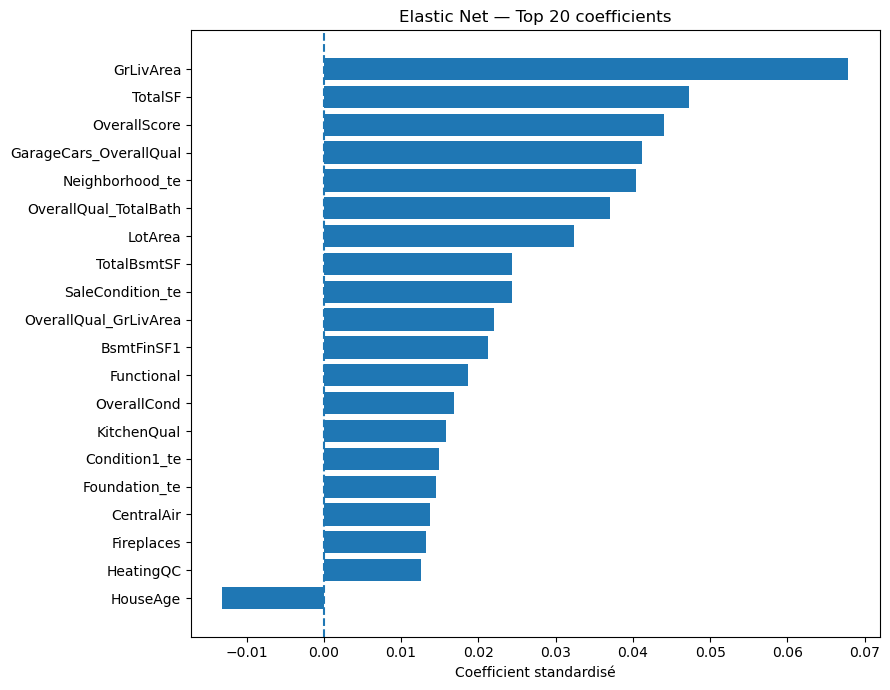

In [17]:
# =============================
# 17. Interprétation des coefficients Elastic Net
# =============================

# Elastic Net est interprétable : chaque variable a un coefficient.
# Un coefficient positif augmente le log-prix prédit.
# Un coefficient négatif diminue le log-prix prédit.
# Comme les variables sont standardisées, les coefficients sont plus comparables entre eux.

coef_df = pd.DataFrame({
    "feature": final_preprocessor.feature_names_,
    "coefficient": final_model.coef_
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("Top 20 variables les plus influentes selon Elastic Net :")
display(coef_df.head(20))

# Visualisation des 20 plus gros coefficients.
top20 = coef_df.head(20).sort_values("coefficient")

plt.figure(figsize=(9, 7))
plt.barh(top20["feature"], top20["coefficient"])
plt.axvline(0, linestyle="--")
plt.title("Elastic Net — Top 20 coefficients")
plt.xlabel("Coefficient standardisé")
plt.tight_layout()
plt.show()

## Interprétation métier des coefficients

Les variables les plus importantes doivent être cohérentes avec le métier.

On s'attend par exemple à retrouver :

- la surface habitable ;
- la qualité globale ;
- la surface totale ;
- le quartier ;
- le nombre de salles de bain ;
- le garage ;
- l'âge de la maison.

Si ces variables ressortent fortement, cela renforce la crédibilité métier du modèle.

Elastic Net peut aussi mettre certains coefficients à zéro. Cela signifie qu'il considère certaines variables comme peu utiles après régularisation.

In [18]:
# =============================
# 18. Génération de la soumission Kaggle
# =============================

# Le modèle prédit log1p(SalePrice). On applique donc expm1 pour revenir au prix réel.

test_pred_log = elastic_pipeline.predict(X_test_final)
test_pred_price = np.expm1(test_pred_log)

# Sécurité : un prix ne peut pas être négatif.
test_pred_price = np.maximum(test_pred_price, 0)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_pred_price
})

submission_path = "elastic_net_final_aligned_M0_submission.csv"
submission.to_csv(submission_path, index=False)

print(f"Fichier Kaggle créé : {submission_path}")
display(submission.head())
print(submission.shape)

Fichier Kaggle créé : elastic_net_final_aligned_M0_submission.csv


,Id,SalePrice
0,1461,112994.707953
1,1462,159242.836091
2,1463,179053.257546
3,1464,199919.646382
4,1465,196997.699715


(1459, 2)


In [19]:
# =============================
# 19. Tableau de synthèse des scores
# =============================

# Le score Kaggle officiel doit être ajouté après soumission.
# Dans nos essais précédents, la meilleure version Elastic Net a obtenu environ 0.12509.

summary = pd.DataFrame([
    {
        "model": "Baseline commune M0 - Linear Regression",
        "rmse_log_cv": baseline_rmse_cv,
        "rmse_log_train": baseline_rmse_train,
        "mae_price_oof": baseline_mae,
        "mape_oof_percent": baseline_mape,
        "kaggle_score": np.nan,
        "comment": "Baseline commune du groupe, point de comparaison"
    },
    {
        "model": "Elastic Net optimisé",
        "rmse_log_cv": elastic_rmse_cv,
        "rmse_log_train": elastic_rmse_train,
        "mae_price_oof": elastic_mae,
        "mape_oof_percent": elastic_mape,
        "kaggle_score": 0.12509,
        "comment": "Meilleure soumission observée pour ma partie Elastic Net"
    }
])

display(summary)
summary.to_csv("elastic_net_final_aligned_M0_summary.csv", index=False)
coef_df.to_csv("elastic_net_final_aligned_M0_coefficients.csv", index=False)

print("Fichiers de synthèse créés :")
print("- elastic_net_final_aligned_M0_summary.csv")
print("- elastic_net_final_aligned_M0_coefficients.csv")

,model,rmse_log_cv,rmse_log_train,mae_price_oof,mape_oof_percent,kaggle_score,comment
0,Baseline commune M0 - Linear Regression,0.155141,0.150302,19779.270999,11.674272,NaN,"Baseline commune du groupe, point de comparaison"
1,Elastic Net optimisé,0.115005,0.107807,14427.475935,8.338489,0.12509,Meilleure soumission observée pour ma partie E...


Fichiers de synthèse créés :
- elastic_net_final_aligned_M0_summary.csv
- elastic_net_final_aligned_M0_coefficients.csv


# 6. Discussion — Choix du modèle

## Pourquoi Elastic Net ?

Elastic Net est pertinent pour ce projet car :

- il est adapté à un problème de régression ;
- il est plus stable qu'une régression linéaire simple ;
- il limite les coefficients trop élevés grâce à la régularisation ;
- il peut réduire l'impact de variables peu utiles ;
- ses coefficients restent interprétables.

## Critère mathématique

Le modèle Elastic Net est comparé à la baseline M0 avec le RMSE sur `log1p(SalePrice)`.

L'objectif est d'obtenir un RMSE plus faible que la baseline.

## Critère informatique

La solution est reproductible car les étapes sont intégrées dans une pipeline :

- preprocessing ;
- encodage ;
- standardisation ;
- entraînement du modèle ;
- prédiction sur test.csv.

Les transformations qui dépendent de la cible sont apprises uniquement sur le train de chaque fold pendant la validation croisée, ce qui limite le risque de fuite de données.

## Critère métier

La MAE et le graphe prix réel vs prix prédit permettent de traduire le score en langage métier.

Pour une banque, une erreur moyenne en dollars est plus facilement interprétable qu'un RMSE logarithmique.

## Limites du modèle

Elastic Net reste un modèle linéaire. Même avec des variables d'interaction, il capture moins bien les relations complexes qu'un modèle comme XGBoost ou LightGBM.

Cela peut expliquer pourquoi l'amélioration Kaggle reste modérée.

# 7. Blueprint & Operation — Production, monitoring et éthique

## Déploiement théorique

Le déploiement demandé dans ce projet correspond à la soumission Kaggle.

Dans un vrai contexte bancaire, le modèle pourrait être exposé via :

- un notebook automatisé ;
- une API interne ;
- un outil d'aide à la décision pour les conseillers.

## Monitoring

En production, il faudrait surveiller :

- l'évolution de l'erreur de prédiction ;
- les écarts entre prix estimé et prix réellement observé ;
- la distribution des variables d'entrée ;
- les performances par segment de maison ou par quartier ;
- les cas où le modèle est très incertain ou très éloigné du prix réel.

## Feedback utilisateur

Les conseillers pourraient signaler :

- les estimations jugées incohérentes ;
- les biens atypiques ;
- les variables manquantes importantes ;
- les cas où l'avis humain contredit fortement le modèle.

## Risques éthiques et légaux

Le modèle utilise des variables comme `Neighborhood`, donc le quartier peut influencer l'estimation.

Cela pose un risque :

- reproduire des biais historiques ;
- défavoriser certaines zones ;
- donner une impression d'objectivité alors que les données passées peuvent contenir des biais.

Il ne faut donc pas utiliser le modèle comme décision automatique. Il doit rester un outil d'aide à la décision, accompagné d'une interprétation humaine.

# 8. Pistes d'amélioration

Les améliorations testées ont permis de faire progresser légèrement le score Kaggle de la version Elastic Net.

Pistes déjà intégrées :

- ajout de variables d'interaction ;
- imputation de `LotFrontage` par quartier ;
- grille plus fine pour `alpha` et `l1_ratio` ;
- validation croisée interne à 5 folds dans `ElasticNetCV`.

Pistes restantes :

- tester un encodage moins agressif pour certaines variables nominales ;
- comparer `StandardScaler` et `RobustScaler` ;
- retirer certaines interactions si elles améliorent le CV mais pas Kaggle ;
- comparer avec les autres modèles du groupe sur les mêmes critères.

## Conclusion

La pipeline Elastic Net améliore clairement la baseline commune M0 en validation interne. Le score Kaggle observé reste proche de 0.125, ce qui montre une généralisation correcte mais aussi les limites d'un modèle linéaire régularisé sur un problème immobilier complexe.

L'intérêt principal d'Elastic Net est son équilibre entre performance, stabilité et interprétabilité.